## Homework 8
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [134]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit_algorithms.gradients import FiniteDiffEstimatorGradient
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import QAOAAnsatz
from qiskit.visualization import plot_histogram
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np

import warnings
from scipy.sparse import SparseEfficiencyWarning

warnings.simplefilter("ignore", SparseEfficiencyWarning)

%matplotlib inline

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
ibmsampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-04-05 18:11:44,782: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-05 18:11:45,265: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-05 18:11:47,245: Using instance: open-instance, plan: open


# Problem 1

# a)

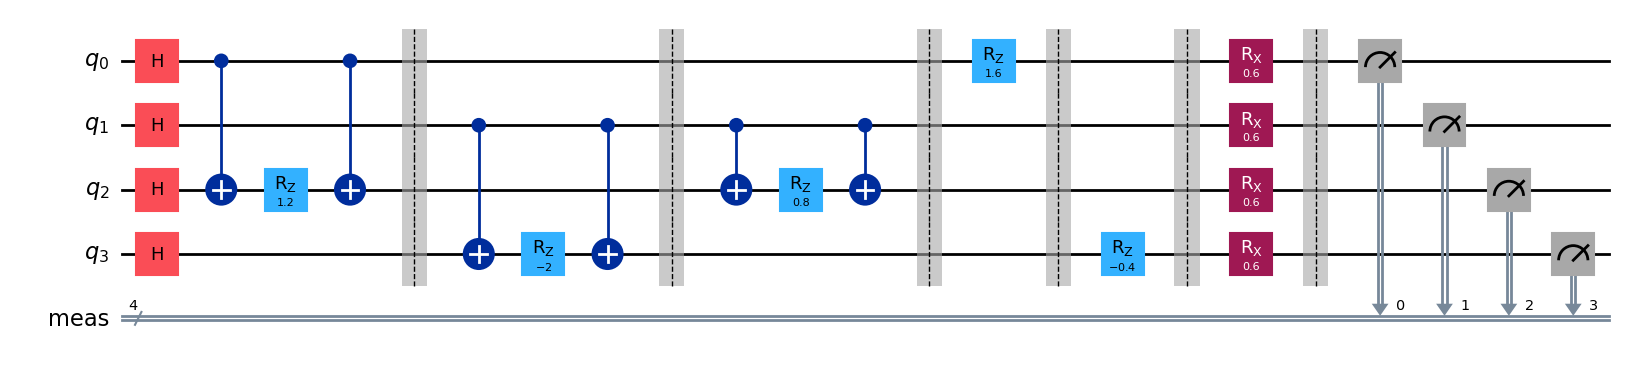

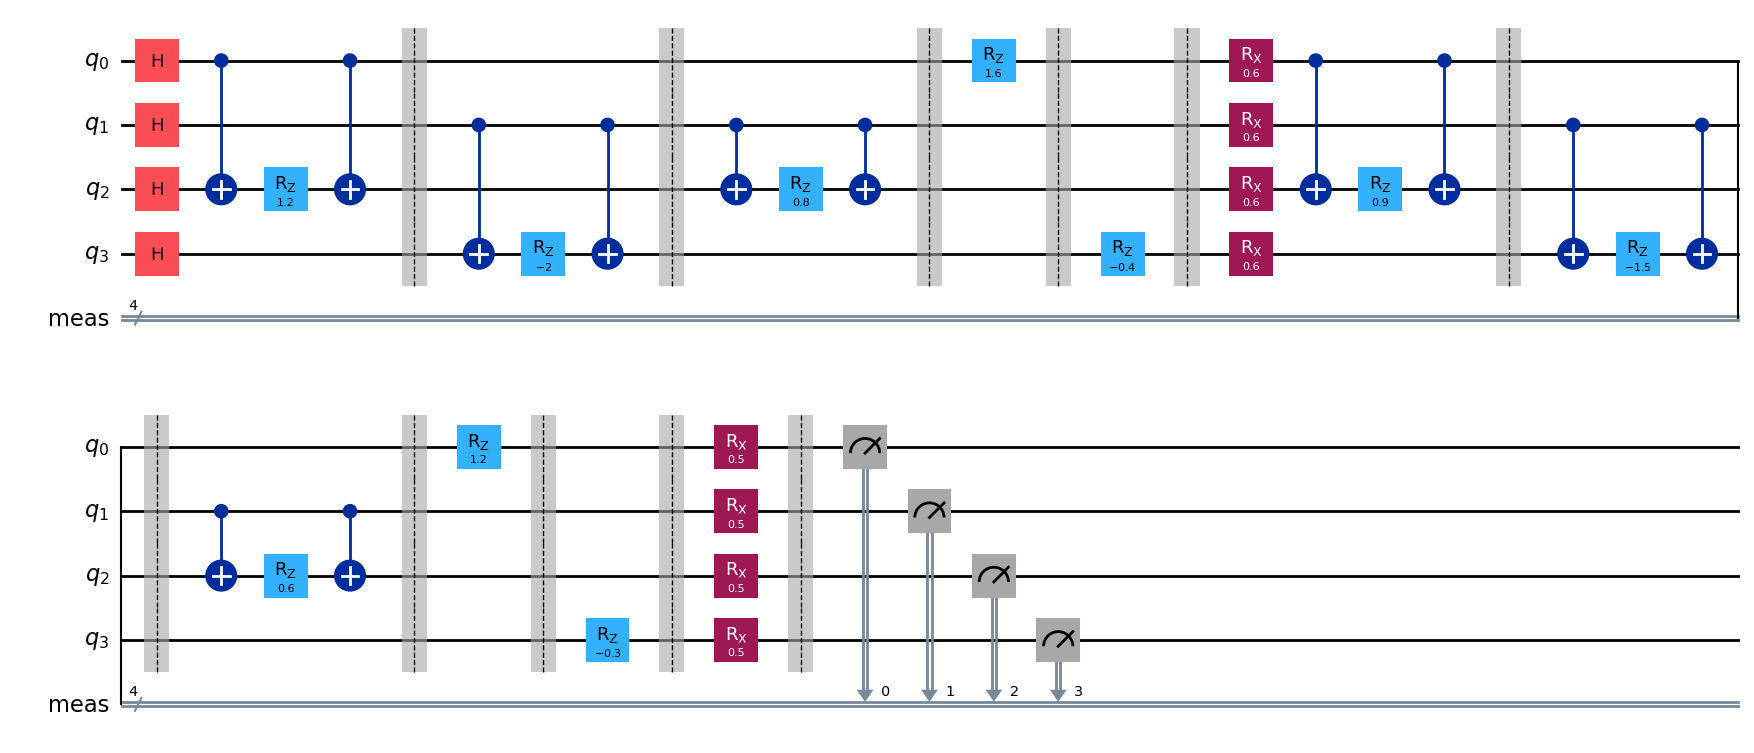

In [13]:
def quad_term(qc, control, target, coeff, alpha):
    qc.cx(control, target)
    qc.rz(2 * coeff * alpha, target)
    qc.cx(control, target)

def lin_term(qc, target, coeff, alpha):
    qc.rz(2 * coeff * alpha, target)

def build_circuit(qc, p ,alpha, beta):
    qc.h([0, 1, 2, 3])
    
    for k in range(p):
        quad_term(qc, 0, 2, 3, alpha[k]) # 3z0z2
        qc.barrier()
        quad_term(qc, 1, 3, -5, alpha[k]) # -5z1z3
        qc.barrier()
        quad_term(qc, 1, 2, 2, alpha[k]) # 2z1z2
        qc.barrier()

        lin_term(qc, 0, 4, alpha[k]) # 4z0
        qc.barrier()
        lin_term(qc, 3, -1, alpha[k]) # -z3
        qc.barrier()

        for q in range(4):
            qc.rx(2 * beta[k], q)
    
    qc.measure_all()


# p = 1
alpha = [0.2]
beta = [0.3]
qc1 = QuantumCircuit(4)
build_circuit(qc1, 1, alpha, beta)
qc1.draw(output='mpl');

# p = 2
alpha = [0.2, 0.15]
beta = [0.3, 0.25]
qc2 = QuantumCircuit(4)
build_circuit(qc2, 2, alpha, beta)
qc2.draw(output='mpl');


In [42]:
H = SparsePauliOp(
    ["ZIZI", "IZIZ", "IZZI", "ZIII", "IIIZ"],
    coeffs=[3, -5, -2, 4, -1]
)

Figure(1207.22x367.889)
Figure(2210.55x367.889)


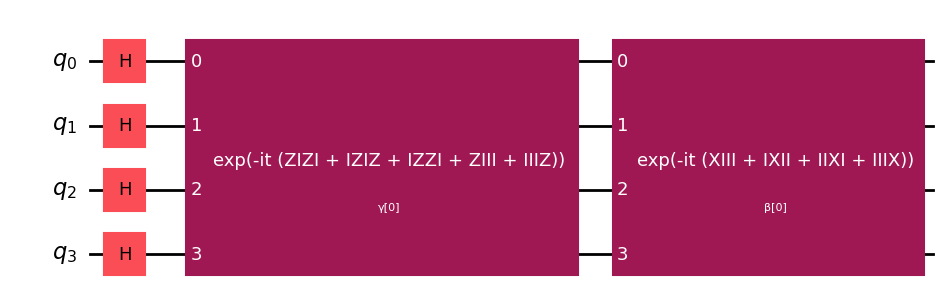

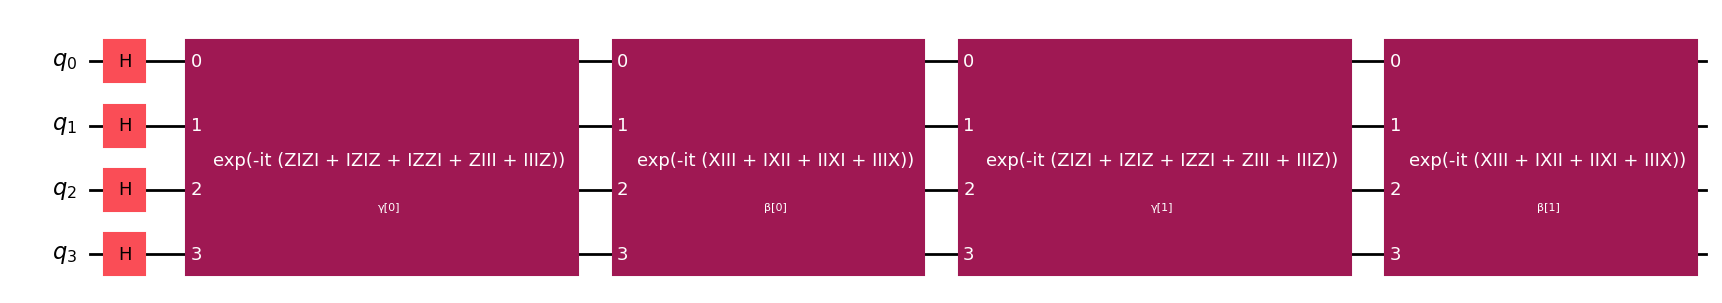

In [43]:
# p = 1
qaoa = QAOAAnsatz(cost_operator=H, reps=1)
print(qaoa.decompose().draw(output='mpl'))

# p = 2
qaoa = QAOAAnsatz(cost_operator=H, reps=2)
print(qaoa.decompose().draw(output='mpl'))

# b) 

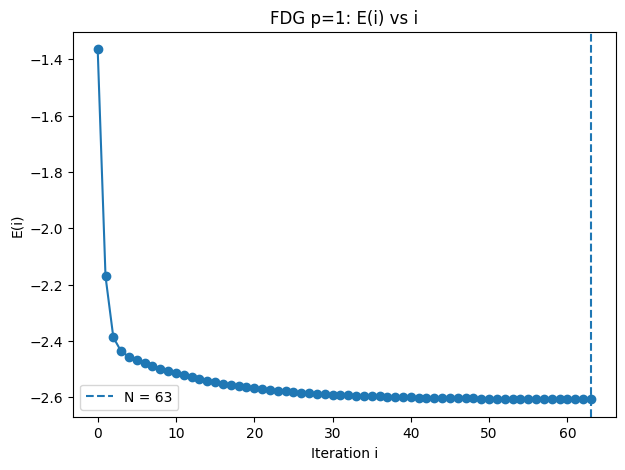

Convergence iteration N = 63
theta = [0.38922349 0.80315879]
energy = -2.607025787968187


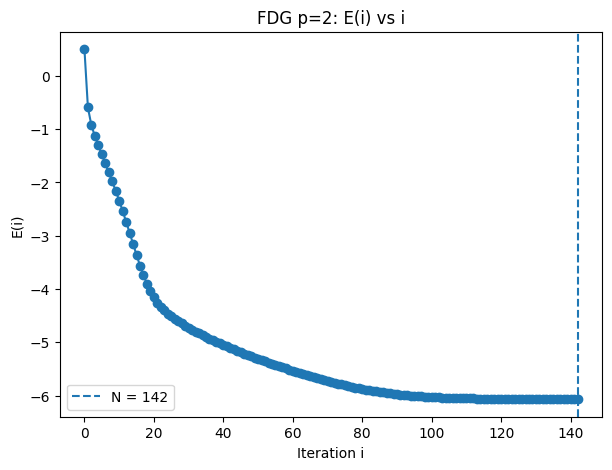

Convergence iteration N = 142
theta = [0.58786095 0.34323296 0.38838386 0.27655754]
energy = -6.068691653861475




In [106]:
# i) finite difference gradient

estimator = StatevectorEstimator()

grad = FiniteDiffEstimatorGradient(
    estimator=estimator,
    epsilon=1e-3,
    method="central"
)

def energy(qc, theta):
    pub = (qc, H, theta)
    result = estimator.run([pub]).result()
    return float(result[0].data.evs)

def train_fd(reps, theta, lr=0.001, tol=1e-4, max_steps=1000):
    qc = QAOAAnsatz(cost_operator=H, reps=reps)
    energies = []
    thetas = []

    step = 0

    while True:
        # compute gradient
        g = np.array(
            grad.run(
                circuits=[qc],
                observables=[H],
                parameter_values=[theta]
            ).result().gradients[0],
            dtype=float
        )


        theta = theta - lr * g
        E = energy(qc, theta)
        energies.append(E)
        thetas.append(theta.copy())

        if step > 0 and abs(energies[step] - energies[step-1]) < tol:
            break

        if step >= max_steps:
            print("Stopped (max steps reached)")
            break

        step += 1
    
    return energies, theta, thetas, step

def plot_energy(energies, iters, title, tol=1e-4):
    iterations = np.arange(len(energies))

    plt.figure(figsize=(7,5))
    plt.plot(iterations, energies, marker='o')
    plt.axvline(iters, linestyle='--', label=f'N = {iters}')
    plt.xlabel("Iteration i")
    plt.ylabel("E(i)")
    plt.title(title)
    plt.legend()
    plt.show()

    print("Convergence iteration N =", iters)

# p = 1 
theta1 = np.array([0.3, 0.7], dtype=float)
energies1, theta1, thetas, iters1 = train_fd(reps=1, theta=theta1)
plot_energy(energies1, iters1, title="FDG p=1: E(i) vs i", tol=1e-4)
print("theta =", theta1)
print("energy =", energies1[-1])

# p = 2
theta2 = np.array([0.3, 0.7, 0.2, 0.5], dtype=float)
energies2, theta2, thetas, iters2 = train_fd(reps=2, theta=theta2)
plot_energy(energies2, iters2, title="FDG p=2: E(i) vs i", tol=1e-4)
print("theta =", theta2)
print("energy =", energies2[-1])
print("\n")


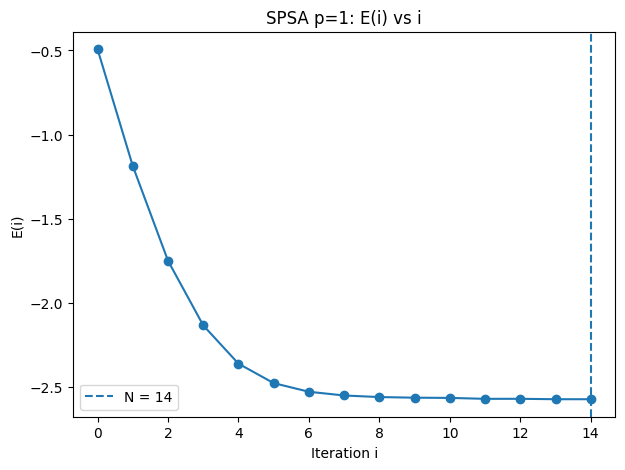

Convergence iteration N = 14

Final p=1:
theta = [0.35565656 0.80202849]
energy = -2.5735788907122243


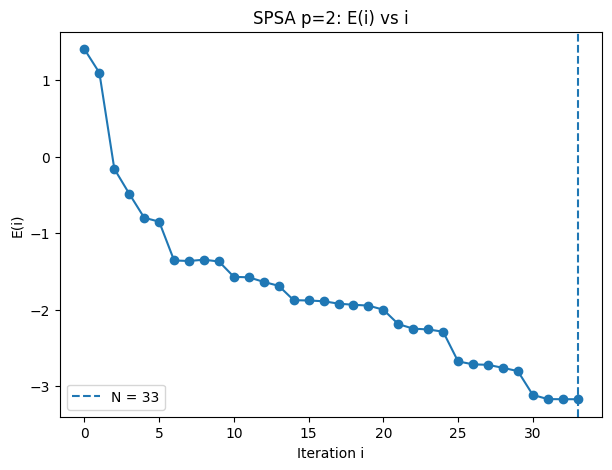

Convergence iteration N = 33

Final p=2:
theta = [0.32344935 0.61941864 0.38667915 0.41023607]
energy = -3.1695415396882805


In [128]:
# ii) SPSA 

def train_spsa(reps, theta, lr=0.0005, eps=0.05, tol=1e-4, max_steps=1000):
    qc = QAOAAnsatz(cost_operator=H, reps=reps)
    energies = []
    thetas = []

    step = 0

    while True:
        # random ±1 vector
        delta = np.random.choice([-1, 1], size=len(theta))

        E_plus  = energy(qc, theta + eps * delta)
        E_minus = energy(qc, theta - eps * delta)
        g = (E_plus - E_minus) / (2 * eps * delta)

        theta = theta - lr * g

        E = energy(qc, theta)
        energies.append(E)
        thetas.append(theta.copy())

        if step > 0 and abs(energies[step] - energies[step-1]) < tol:
            break

        if step >= max_steps:
            print("Stopped (max steps reached)")
            break

        step += 1

    return energies, theta, thetas, step



# p = 1
theta1 = np.array([0.3, 0.7], dtype=float)
energies1, theta1, thetas, iters1 = train_spsa(reps=1, theta=theta1)
plot_energy(energies1, iters1, title="SPSA p=1: E(i) vs i", tol=1e-4)
print("\nFinal p=1:")
print("theta =", theta1)
print("energy =", energies1[-1])

# p = 2
theta2 = np.array([0.3, 0.7, 0.2, 0.5], dtype=float)
energies2, theta2, thetas, iters2 = train_spsa(reps=2, theta=theta2)
plot_energy(energies2, iters2, title="SPSA p=2: E(i) vs i", tol=1e-4)
print("\nFinal p=2:")
print("theta =", theta2)
print("energy =", energies2[-1])

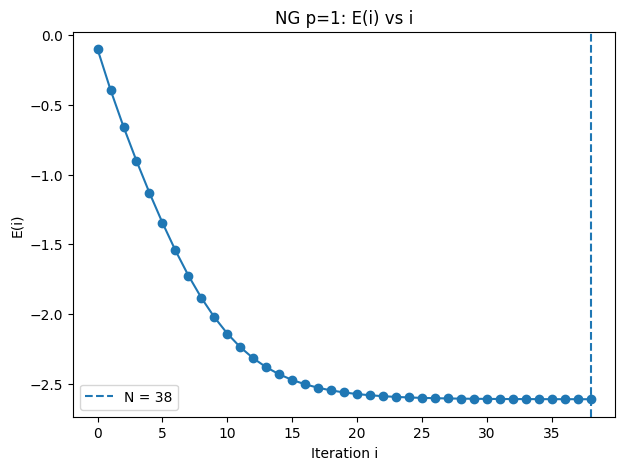

Convergence iteration N = 38

Final p=1:
theta = [0.3962992  0.80226177]
energy = -2.6078661714084808


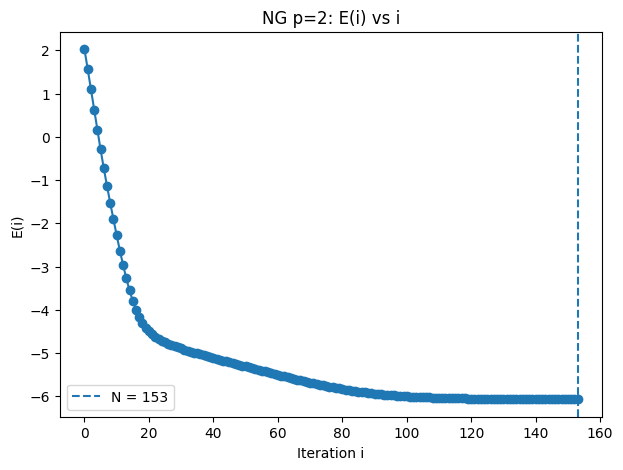

Convergence iteration N = 153

Final p=2:
theta = [0.58989476 0.34679616 0.38881781 0.27754904]
energy = -6.068538617208754


In [131]:
# iii) natural gradient

def metric_tensor(qc, theta, eps=1e-3):
    n = len(theta)
    psi = Statevector.from_instruction(qc.assign_parameters(theta)).data

    dpsis = []
    for i in range(n):
        shift = np.zeros(n)
        shift[i] = eps

        psi_plus = Statevector.from_instruction(qc.assign_parameters(theta + shift)).data
        psi_minus = Statevector.from_instruction(qc.assign_parameters(theta - shift)).data

        dpsi = (psi_plus - psi_minus) / (2 * eps)
        dpsis.append(dpsi)

    G = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(n):
            term1 = np.vdot(dpsis[i], dpsis[j])
            term2 = np.vdot(dpsis[i], psi) * np.vdot(psi, dpsis[j])
            G[i, j] = np.real(term1 - term2)

    return G

def train_ng(reps, theta, lr=0.01, tol=1e-4, max_steps=1000, reg=1e-6):
    qc = QAOAAnsatz(cost_operator=H, reps=reps)
    energies = []
    thetas = []

    step = 0

    while True:
        # ordinary gradient
        g = np.array(
            grad.run(
                circuits=[qc],
                observables=[H],
                parameter_values=[theta]
            ).result().gradients[0],
            dtype=float
        )

        G = metric_tensor(qc, theta)

        # regularize so inverse is stable
        G_reg = G + reg * np.eye(len(theta))

        # natural gradient step: G^{-1} g
        nat_grad = np.linalg.solve(G_reg, g)

        theta = theta - lr * nat_grad

        E = energy(qc, theta)
        energies.append(E)
        thetas.append(theta.copy())

        if step > 0 and abs(energies[-1] - energies[-2]) < tol:
            break

        if step >= max_steps:
            print("Stopped (max steps reached)")
            break

        step += 1

    return energies, theta, thetas, step

# p = 1
theta1 = np.array([0.3, 0.7], dtype=float)
energies1, theta1, thetas, iters1 = train_ng(reps=1, theta=theta1)
plot_energy(energies1, iters1, title="NG p=1: E(i) vs i", tol=1e-4)
print("\nFinal p=1:")
print("theta =", theta1)
print("energy =", energies1[-1])

# p = 2
theta2 = np.array([0.3, 0.7, 0.2, 0.5], dtype=float)
energies2, theta2, thetas, iters2 = train_ng(reps=2, theta=theta2)
plot_energy(energies2, iters2, title="NG p=2: E(i) vs i", tol=1e-4)
print("\nFinal p=2:")
print("theta =", theta2)
print("energy =", energies2[-1])

# c) 

In [125]:
def run_histograms(reps, thetas, N, title, shots=2000):
    qc = QAOAAnsatz(cost_operator=H, reps=reps)

    i1 = N // 3
    i2 = N

    theta_1 = thetas[i1]
    theta_2 = thetas[i2]

    sampler = StatevectorSampler()

    # add measurements
    circ1 = qc.assign_parameters(theta_1).decompose()
    circ1.measure_all()

    circ2 = qc.assign_parameters(theta_2).decompose()
    circ2.measure_all()

    result1 = sampler.run([circ1], shots=shots).result()
    result2 = sampler.run([circ2], shots=shots).result()

    counts1 = result1[0].data.meas.get_counts()
    counts2 = result2[0].data.meas.get_counts()

    plot_histogram(counts1, title= title +f"at i = N/3 = {i1}")
    plt.show()

    plot_histogram(counts2, title= title + f"at i = N = {i2}")
    plt.show()

    return counts1, counts2

def check_optimality(counts):
    most_probable = max(counts, key=counts.get)
    E_most = bit_energy_qaoa(most_probable)

    print("Most probable histogram state:", most_probable)
    print("Energy of most probable state:", E_most)
        
def bit_energy_qaoa(x):
    z0 = 1 if x[0] == '0' else -1
    z1 = 1 if x[1] == '0' else -1
    z2 = 1 if x[2] == '0' else -1
    z3 = 1 if x[3] == '0' else -1

    return 3*z0*z2 - 5*z1*z3 - 2*z1*z2 + 4*z0 - z3


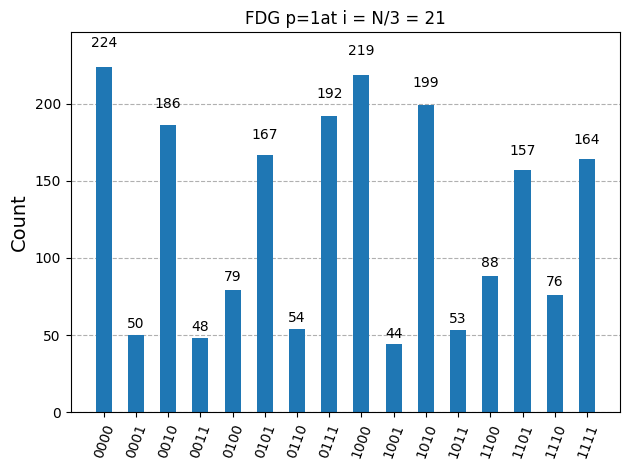

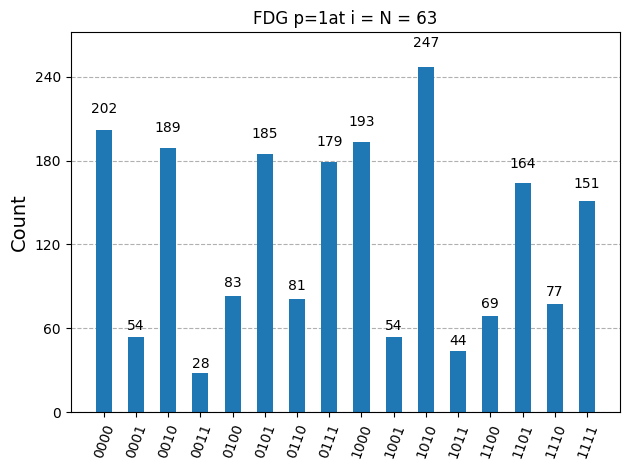


Check optimality at i = N/3
Most probable histogram state: 0000
Energy of most probable state: -1

Check optimality at i = N
Most probable histogram state: 1010
Energy of most probable state: -5


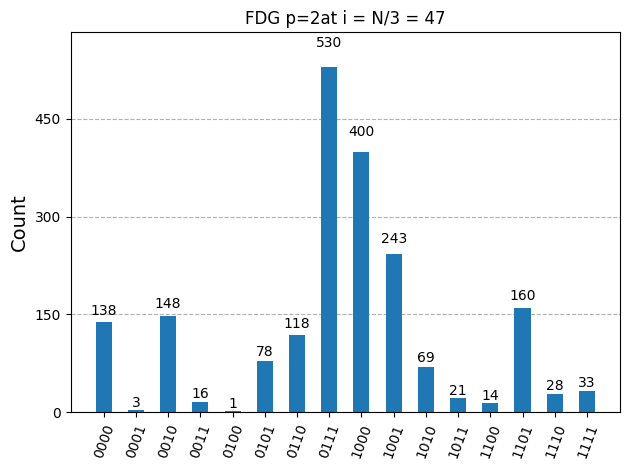

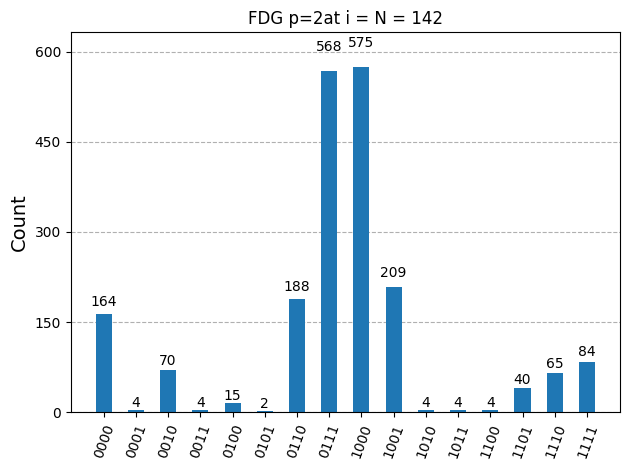


Check optimality at i = N/3
Most probable histogram state: 0111
Energy of most probable state: -5

Check optimality at i = N
Most probable histogram state: 1000
Energy of most probable state: -15


In [ ]:
# finite difference gradient

# p = 1
theta1 = np.array([0.3, 0.7], dtype=float)
energies, theta_opt, thetas, N = train_fd(reps=1, theta=theta1)
counts_N3, counts_N = run_histograms(reps = 1, thetas = thetas, N = N, title="FDG p=1")
print("\nCheck optimality at i = N/3")
check_optimality(counts_N3)
print("\nCheck optimality at i = N")
check_optimality(counts_N)

# p = 2
theta2 = np.array([0.3, 0.7, 0.2, 0.5], dtype=float)
energies, theta_opt, thetas, N = train_fd(reps=2, theta=theta2)
counts_N3, counts_N = run_histograms(reps = 2, thetas = thetas, N = N, title="FDG p=2")
print("\nCheck optimality at i = N/3")
check_optimality(counts_N3)
print("\nCheck optimality at i = N")
check_optimality(counts_N)

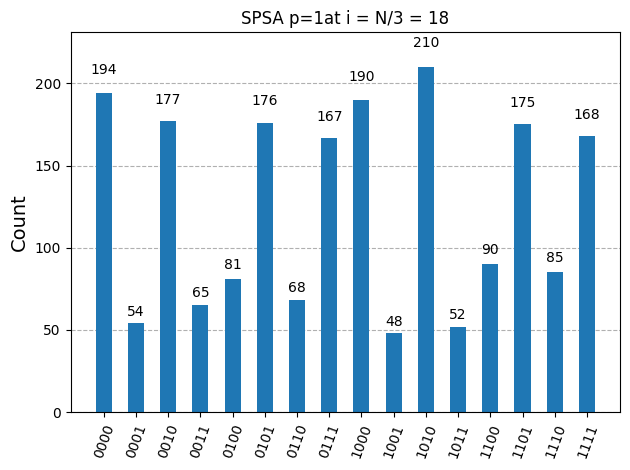

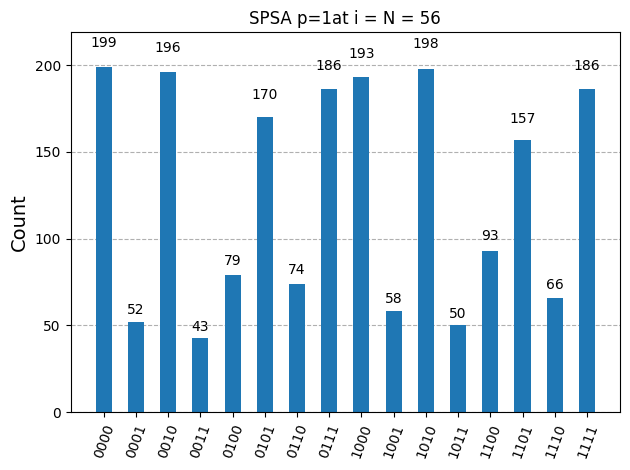


Check optimality at i = N/3
Most probable histogram state: 1010
Energy of most probable state: -5

Check optimality at i = N
Most probable histogram state: 0000
Energy of most probable state: -1


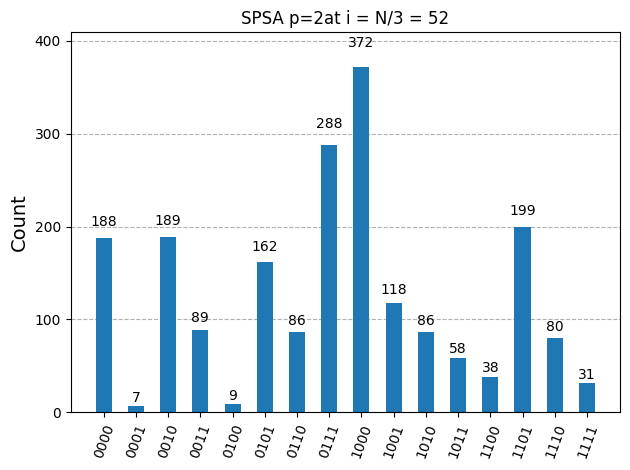

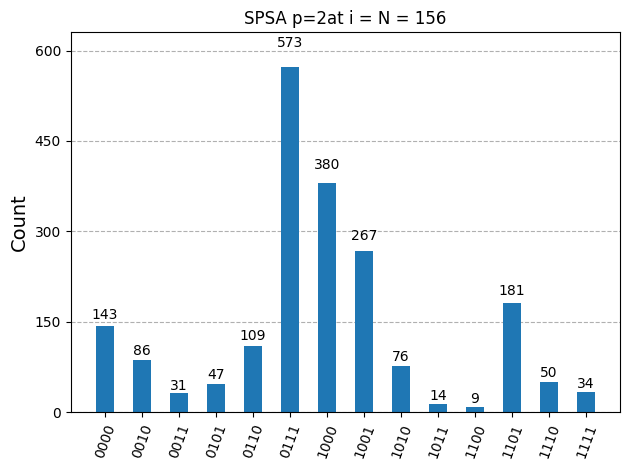


Check optimality at i = N/3
Most probable histogram state: 1000
Energy of most probable state: -15

Check optimality at i = N
Most probable histogram state: 0111
Energy of most probable state: -5


In [129]:
# SPSA

# p = 1
theta1 = np.array([0.3, 0.7], dtype=float)
energies, theta_opt, thetas, N = train_spsa(reps=1, theta=theta1)
counts_N3, counts_N = run_histograms(reps = 1, thetas = thetas, N = N, title="SPSA p=1")
print("\nCheck optimality at i = N/3")
check_optimality(counts_N3)
print("\nCheck optimality at i = N")
check_optimality(counts_N)

# p = 2
theta2 = np.array([0.3, 0.7, 0.2, 0.5], dtype=float)
energies, theta_opt, thetas, N = train_spsa(reps=2, theta=theta2)
counts_N3, counts_N = run_histograms(reps = 2, thetas = thetas, N = N, title="SPSA p=2")
print("\nCheck optimality at i = N/3")
check_optimality(counts_N3)
print("\nCheck optimality at i = N")
check_optimality(counts_N)

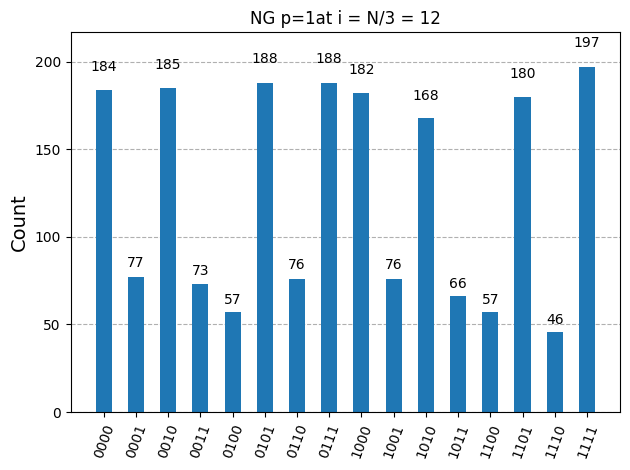

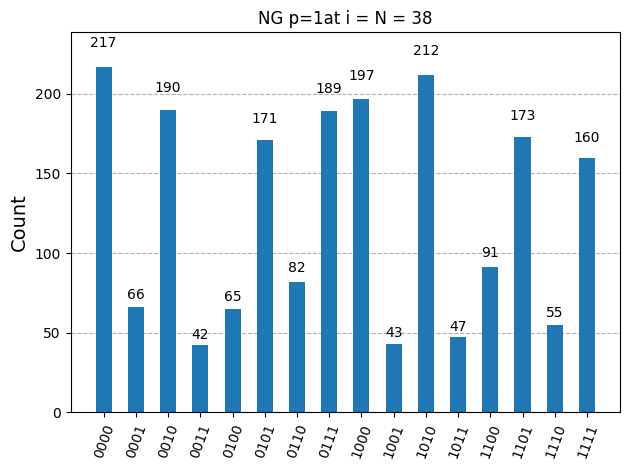


Check optimality at i = N/3
Most probable histogram state: 1111
Energy of most probable state: -7

Check optimality at i = N
Most probable histogram state: 0000
Energy of most probable state: -1


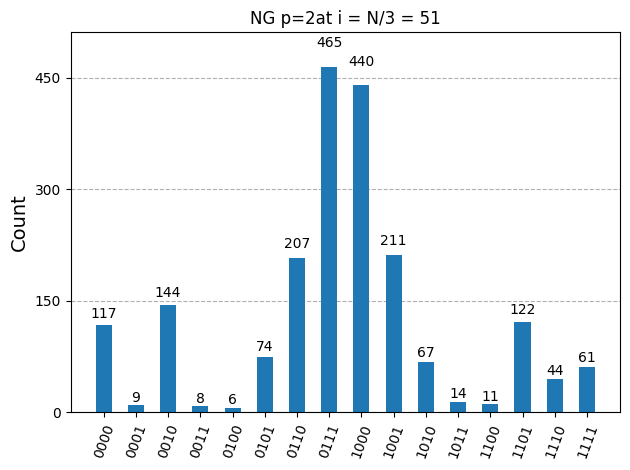

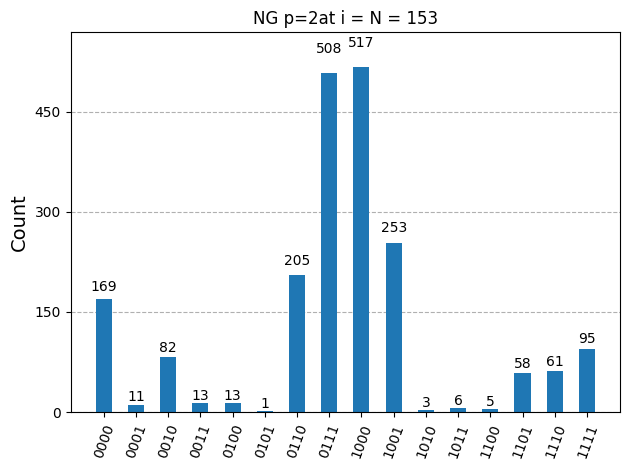


Check optimality at i = N/3
Most probable histogram state: 0111
Energy of most probable state: -5

Check optimality at i = N
Most probable histogram state: 1000
Energy of most probable state: -15


In [132]:
# NG

# p = 1
theta1 = np.array([0.3, 0.7], dtype=float)
energies, theta_opt, thetas, N = train_ng(reps=1, theta=theta1)
counts_N3, counts_N = run_histograms(reps = 1, thetas = thetas, N = N, title="NG p=1")
print("\nCheck optimality at i = N/3")
check_optimality(counts_N3)
print("\nCheck optimality at i = N")
check_optimality(counts_N)

# p = 2
theta2 = np.array([0.3, 0.7, 0.2, 0.5], dtype=float)
energies, theta_opt, thetas, N = train_ng(reps=2, theta=theta2)
counts_N3, counts_N = run_histograms(reps = 2, thetas = thetas, N = N, title="NG p=2")
print("\nCheck optimality at i = N/3")
check_optimality(counts_N3)
print("\nCheck optimality at i = N")
check_optimality(counts_N)

# Problem 3

# a)

Counts: {'0101': 542, '1001': 170, '1100': 146, '1010': 567, '0011': 160, '1111': 32, '0001': 23, '1101': 40, '0000': 26, '0110': 166, '1011': 36, '0111': 33, '0100': 35, '0010': 24, '1110': 25, '1000': 23}


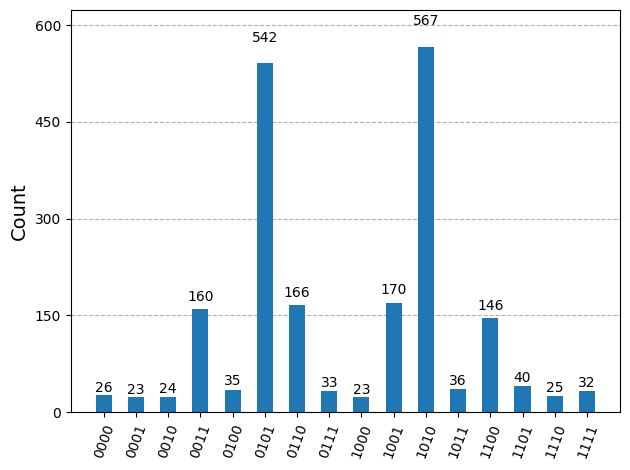

Most probable state: 1010
Cut value: 4


In [159]:
# square graph
n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]

paulis = []
for i, j in edges:
    z = ['I'] * n
    z[i] = 'Z'
    z[j] = 'Z'
    paulis.append(("".join(z), 1.0))

H = SparsePauliOp.from_list(paulis)

def cut_value(bitstring, edges):
    x = [int(b) for b in bitstring]
    return sum(x[i] != x[j] for i, j in edges)

ansatz = QAOAAnsatz(cost_operator=H, reps=1)

estimator = StatevectorEstimator()

def objective(theta):
    pub = (ansatz, H, [theta])
    result = estimator.run([pub]).result()
    return result[0].data.evs[0]


thetas = np.random.uniform(0, 2 * np.pi, ansatz.num_parameters)

res = minimize(objective, thetas, method="COBYLA")

qc = ansatz.assign_parameters(res.x)
qc.measure_all()
sampler = StatevectorSampler()
result = sampler.run([qc], shots=2048).result()
counts = result[0].data.meas.get_counts()

print("Counts:", counts)
plot_histogram(counts)
plt.show()

best_state = max(counts, key=counts.get)
print("Most probable state:", best_state)
print("Cut value:", cut_value(best_state, edges))